# DL Toll Monitoring


## 1. Imports


In [ ]:
from google.colab import files
from IPython.display import HTML, display
from pathlib import Path
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
import os
import os, sys
import pandas as pd
import sys
import sys, os
import sys, subprocess, importlib
import torch
import torch.nn as nn


## 2. Data Loading & Preprocessing


# TolJam BI Decision Support (Notebook App / .ipynb)

- **Dataset**: `data_tol.xlsx` (kolom A–F = gerbang tol; isi sel = timestamp event mobil)
- **Pre-processing**: dataset dirapihkan sehingga **setiap baris = 1 timestamp yang sama (union)**, dibuat label:
  - 1–2 mobil → **LOW**
  - 3–4 mobil → **MEDIUM**
  - 5–6 mobil → **HEAVY**
- **Deep Learning**: Fully-connected / Dense (MLP)
- **Final output**: **keputusan GO / NOT GO**

---

## Google Colab

> Di bagian paling bawah, akan muncul UI **Gradio** (mini-app):
   - Input kondisi 6 gate **atau** pilih timestamp historis
   - Output: `Prob Congested`, `Predicted Label`, dan keputusan **GO/NOT GO**

> Catatan: kalau Anda menyimpan data di Google Drive, bisa pakai `drive.mount()` (lihat cell setup).

---

## Output file yang akan dihasilkan
- `data_tol_aligned.xlsx` (hasil rapih sesuai instruksi)
- `data_tol_clean.csv` (fitur 0/1 per gate + label)
- `mlp_tolgate.pt` (model MLP terlatih)



In [ ]:
# ==== SETUP: install dependensi bila perlu (Colab biasanya sudah ada pandas/numpy/sklearn/matplotlib/torch) ====

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pkg])

for pkg in ["openpyxl", "gradio"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        pip_install(pkg)

print("Setup OK")


Setup OK


In [ ]:
# ==== (OPSIONAL) Upload file di Colab ====
# Jika Anda menjalankan di Colab dan belum upload data_tol.xlsx, jalankan cell ini.
# Kalau sudah upload lewat panel Files, cell ini bisa di-skip.


IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("data_tol.xlsx"):
        print("Upload data_tol.xlsx ...")
        uploaded = files.upload()  # pilih file data_tol.xlsx
    else:
        print("data_tol.xlsx sudah ada.")
else:
    print("Bukan Colab (local Jupyter). Pastikan data_tol.xlsx ada di folder yang sama.")


data_tol.xlsx sudah ada.


In [ ]:
# ==== (OPSIONAL) Mount Google Drive (jika dataset disimpan di Drive) ====
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = "/content/drive/MyDrive/path/to/data_tol.xlsx"


In [ ]:
torch.set_num_threads(1)

DATA_PATH = "data_tol.xlsx"   # ganti jika pakai Google Drive
MODEL_PATH = "mlp_tolgate.pt"

GATE_COLS = ["G1", "G2", "G3", "G4", "G5", "G6"]

# reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("OK: imports selesai.")


OK: imports selesai.


In [ ]:
# ==== Load dataset mentah ====
assert os.path.exists(DATA_PATH), f"File tidak ditemukan: {DATA_PATH}"

df_raw = pd.read_excel(DATA_PATH, header=None)
df_raw = df_raw.iloc[:, :6].copy()
df_raw.columns = GATE_COLS

display(df_raw.head(10))
print("Shape raw:", df_raw.shape)


,G1,G2,G3,G4,G5,G6
0,1970-01-01 00:00:01,1970-01-01 00:00:00,1970-01-01 00:00:00,1970-01-01 00:00:07,1970-01-01 00:00:00,1970-01-01 00:00:07
1,1970-01-01 00:00:10,1970-01-01 00:00:10,1970-01-01 00:00:09,1970-01-01 00:00:18,1970-01-01 00:00:09,1970-01-01 00:00:30
2,1970-01-01 00:00:20,1970-01-01 00:00:21,1970-01-01 00:00:19,1970-01-01 00:00:27,1970-01-01 00:00:30,1970-01-01 00:00:41
3,1970-01-01 00:00:31,1970-01-01 00:00:31,1970-01-01 00:00:28,1970-01-01 00:01:02,1970-01-01 00:00:41,1970-01-01 00:01:00
4,1970-01-01 00:00:44,1970-01-01 00:00:41,1970-01-01 00:00:38,1970-01-01 00:01:13,1970-01-01 00:00:56,1970-01-01 00:01:16
5,1970-01-01 00:00:54,1970-01-01 00:00:50,1970-01-01 00:00:49,1970-01-01 00:01:22,1970-01-01 00:01:08,1970-01-01 00:01:44
6,1970-01-01 00:01:04,1970-01-01 00:01:01,1970-01-01 00:01:00,1970-01-01 00:01:36,1970-01-01 00:01:25,1970-01-01 00:01:54
7,1970-01-01 00:01:14,1970-01-01 00:01:11,1970-01-01 00:01:09,1970-01-01 00:01:47,1970-01-01 00:01:37,1970-01-01 00:02:07
8,1970-01-01 00:01:24,1970-01-01 00:01:21,1970-01-01 00:01:19,1970-01-01 00:02:00,1970-01-01 00:01:47,1970-01-01 00:02:19
9,1970-01-01 00:01:35,1970-01-01 00:01:32,1970-01-01 00:01:30,1970-01-01 00:02:20,1970-01-01 00:01:56,1970-01-01 00:02:31


Shape raw: (180, 6)


## 1) Pre-processing: rapihkan menjadi 1 timestamp per baris

Data mentah: tiap kolom berisi daftar timestamp event untuk 1 gerbang.

Langkah:
1. Buat daftar event `(timestamp, gate)` dari semua kolom.
2. Buat tabel `aligned` dengan **index = timestamp union**, kolom = gate.
3. Buat **dua versi output**:
   - **`df_view` (untuk Excel, sesuai instruksi)**: kolom A–F berisi **timestamp yang sama** (atau kosong/NaN) untuk tiap gate, plus kolom label.
   - **`df` (untuk model DL & BI)**: fitur numerik 0/1 per gate + `total_cars` + `label`.
4. Buat label LOW/MEDIUM/HEAVY:
   - 1–2 mobil → LOW
   - 3–4 mobil → MEDIUM
   - 5–6 mobil → HEAVY


In [ ]:
def build_aligned_tables(df_raw: pd.DataFrame, gate_cols=GATE_COLS):
    # 1) Ubah ke event list (timestamp, gate)
    events = []
    for g in gate_cols:
        s = df_raw[g].dropna()
        for ts in s:
            events.append((ts, g))
    events_df = pd.DataFrame(events, columns=["timestamp", "gate"])

    # 2) Hitung event per timestamp per gate (biasanya 0/1)
    counts = pd.crosstab(events_df["timestamp"], events_df["gate"]).sort_index()
    counts = counts.reindex(columns=gate_cols, fill_value=0)

    # 3) Jadikan fitur binary (0/1)
    feat = (counts > 0).astype(int)

    # 4) total cars & label
    total_cars = feat.sum(axis=1)

    def to_label(n: int) -> str:
        if 1 <= n <= 2:
            return "LOW"
        if 3 <= n <= 4:
            return "MEDIUM"
        if 5 <= n <= 6:
            return "HEAVY"
        return "UNKNOWN"

    label = total_cars.apply(lambda x: to_label(int(x)))

    # === df (untuk DL & BI): 0/1 + timestamp + total + label
    df = feat.copy()
    df["total_cars"] = total_cars
    df["label"] = label
    df = df.reset_index().rename(columns={"timestamp": "timestamp"})

    # === df_view (untuk Excel): kolom gate berisi timestamp yang sama (atau kosong) + label
    view = pd.DataFrame(index=feat.index)
    for g in gate_cols:
        # jika gate aktif, tulis timestamp (sama dengan index); jika tidak, NaT/NaN
        view[g] = feat.index.where(feat[g] > 0)
    view["label"] = label
    view = view.reset_index(drop=True)  # index sudah "ditulis" ke dalam cell gate

    return df, view

df, df_view = build_aligned_tables(df_raw)

print("Preview df (untuk DL/BI):")
display(df.head(10))

print("Preview df_view (untuk Excel sesuai instruksi A–F timestamp yang sama):")
display(df_view.head(10))

print("Distribusi label:")
print(df["label"].value_counts(dropna=False))


Preview df (untuk DL/BI):


gate,timestamp,G1,G2,G3,G4,G5,G6,total_cars,label
0,1970-01-01 00:00:00,0,1,1,0,1,0,3,MEDIUM
1,1970-01-01 00:00:01,1,0,0,0,0,0,1,LOW
2,1970-01-01 00:00:07,0,0,0,1,0,1,2,LOW
3,1970-01-01 00:00:09,0,0,1,0,1,0,2,LOW
4,1970-01-01 00:00:10,1,1,0,0,0,0,2,LOW
5,1970-01-01 00:00:18,0,0,0,1,0,0,1,LOW
6,1970-01-01 00:00:19,0,0,1,0,0,0,1,LOW
7,1970-01-01 00:00:20,1,0,0,0,0,0,1,LOW
8,1970-01-01 00:00:21,0,1,0,0,0,0,1,LOW
9,1970-01-01 00:00:27,0,0,0,1,0,0,1,LOW


Preview df_view (untuk Excel sesuai instruksi A–F timestamp yang sama):


,G1,G2,G3,G4,G5,G6,label
0,NaT,1970-01-01 00:00:00,1970-01-01 00:00:00,NaT,1970-01-01 00:00:00,NaT,MEDIUM
1,1970-01-01 00:00:01,NaT,NaT,NaT,NaT,NaT,LOW
2,NaT,NaT,NaT,1970-01-01 00:00:07,NaT,1970-01-01 00:00:07,LOW
3,NaT,NaT,1970-01-01 00:00:09,NaT,1970-01-01 00:00:09,NaT,LOW
4,1970-01-01 00:00:10,1970-01-01 00:00:10,NaT,NaT,NaT,NaT,LOW
5,NaT,NaT,NaT,1970-01-01 00:00:18,NaT,NaT,LOW
6,NaT,NaT,1970-01-01 00:00:19,NaT,NaT,NaT,LOW
7,1970-01-01 00:00:20,NaT,NaT,NaT,NaT,NaT,LOW
8,NaT,1970-01-01 00:00:21,NaT,NaT,NaT,NaT,LOW
9,NaT,NaT,NaT,1970-01-01 00:00:27,NaT,NaT,LOW


Distribusi label:
label
LOW       852
MEDIUM     27
HEAVY       1
Name: count, dtype: int64


In [ ]:
# Simpan hasil rapih
# - data_tol_aligned.xlsx: kolom A–F = gate (isi timestamp yang sama / kosong), kolom label
# - data_tol_clean.csv: untuk training model (0/1 + timestamp + total_cars + label)

df_view.to_excel("data_tol_aligned.xlsx", index=False)
df.to_csv("data_tol_clean.csv", index=False)

print("Saved: data_tol_aligned.xlsx dan data_tol_clean.csv")


Saved: data_tol_aligned.xlsx dan data_tol_clean.csv


## 2) Extract hidden pattern
Karena fitur adalah 6 gate (binary), kita bisa lihat **pola kombinasi gate** yang sering terjadi pada timestamp yang sama.
Ini berguna untuk insight BI: misalnya kombinasi gate tertentu sering padat bersamaan.


,pattern,count
0,G3,131
1,G1,121
2,G2,118
3,G4,115
4,G5,113
5,G6,112
6,G4+G5,15
7,G1+G5,14
8,G4+G6,12
9,G1+G6,11


gate,G1,G2,G3,G4,G5,G6
gate,,,,,,
G1,1.000000,-0.131429,-0.180317,-0.201270,-0.124444,-0.166349
G2,-0.131429,1.000000,-0.173333,-0.145397,-0.152381,-0.103492
G3,-0.180317,-0.173333,1.000000,-0.152381,-0.166349,-0.159365
G4,-0.201270,-0.145397,-0.152381,1.000000,-0.117460,-0.103492
G5,-0.124444,-0.152381,-0.166349,-0.117460,1.000000,-0.152381
G6,-0.166349,-0.103492,-0.159365,-0.103492,-0.152381,1.000000


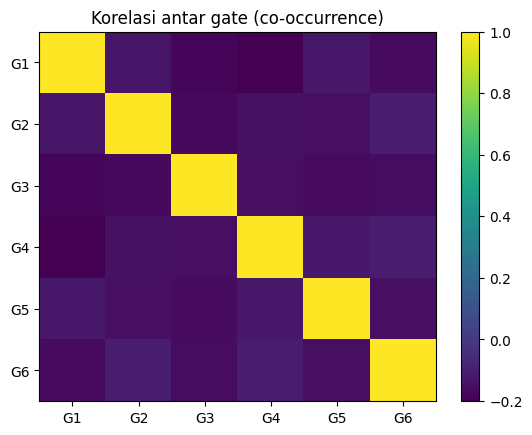

In [ ]:
# Buat pattern string: gate apa saja yang aktif pada timestamp ts
def pattern_row(row):
    active = [g for g in GATE_COLS if row[g] > 0]
    return "+".join(active) if active else "(none)"

df["pattern"] = df.apply(pattern_row, axis=1)

top_patterns = df["pattern"].value_counts().head(15).reset_index()
top_patterns.columns = ["pattern", "count"]
display(top_patterns)

# Co-occurrence / korelasi antar gate (pola keterkaitan)
corr = df[GATE_COLS].corr()
display(corr)

plt.figure()
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(GATE_COLS)), GATE_COLS)
plt.yticks(range(len(GATE_COLS)), GATE_COLS)
plt.title("Korelasi antar gate (co-occurrence)")
plt.colorbar()
plt.show()


## 3) BI dashboard mini (di notebook)

- Distribusi label
- Trend total_cars per timestamp


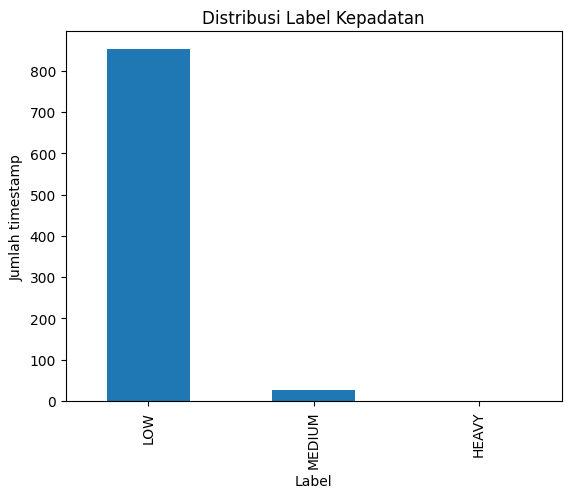

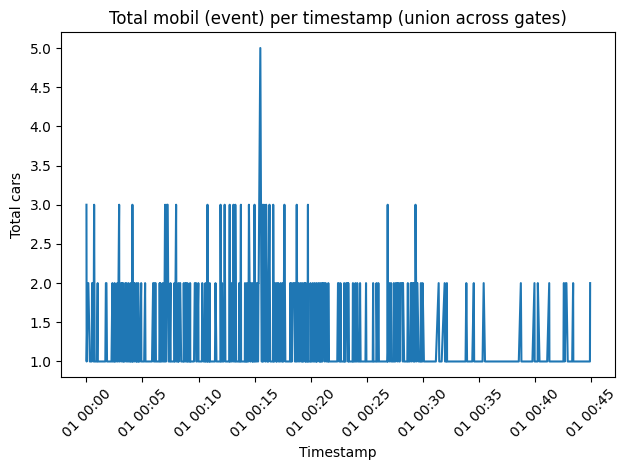

In [ ]:
# Distribusi label
counts = df["label"].value_counts()
plt.figure()
counts.plot(kind="bar")
plt.title("Distribusi Label Kepadatan")
plt.xlabel("Label")
plt.ylabel("Jumlah timestamp")
plt.show()

# Time series total_cars
plt.figure()
plt.plot(df["timestamp"], df["total_cars"])
plt.title("Total mobil (event) per timestamp (union across gates)")
plt.xlabel("Timestamp")
plt.ylabel("Total cars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4) Deep Learning: Fully-connected / Dense (MLP)

Target training dibuat **binary** untuk keputusan:
- `congested = 1` jika label MEDIUM atau HEAVY
- `congested = 0` jika label LOW

Input: 6 gate (G1..G6)  
Output: probabilitas `congested` → dipakai untuk keputusan GO/NOT GO.


In [ ]:
# Build X (fitur) dan y (target binary)
X = df[GATE_COLS].astype(np.float32).values
y = df["label"].isin(["MEDIUM", "HEAVY"]).astype(np.int64).values  # 1 = congested

# Split stratified (karena imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("y train counts:", np.bincount(y_train))
print("y test counts:", np.bincount(y_test))


Train: (704, 6) Test: (176, 6)
y train counts: [682  22]
y test counts: [170   6]


In [ ]:
class MLPBinaryCongestion(nn.Module):
    def __init__(self, in_dim=6, h1=32, h2=16, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, 1),  # logits
        )

    def forward(self, x):
        return self.net(x)

def train_mlp(X_train, y_train, X_test, y_test,
              epochs=150, batch_size=64, lr=1e-2, weight_decay=1e-4):
    device = torch.device("cpu")

    model = MLPBinaryCongestion(in_dim=X_train.shape[1])
    model.to(device)

    # class weight untuk imbalance
    classes = np.array([0, 1])
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    # pos_weight di BCEWithLogitsLoss = w_pos / w_neg
    pos_weight = torch.tensor([cw[1] / cw[0]], dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.float32).view(-1, 1))
    test_X = torch.tensor(X_test, dtype=torch.float32)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    best_f1 = -1.0
    best_state = None

    def f1_for_threshold(probs, y_true, thr=0.5):
        pred = (probs >= thr).astype(int)
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())
        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        return f1, precision, recall

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optim.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optim.step()
            total_loss += loss.item() * xb.size(0)

        if epoch % 10 == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                logits = model(test_X).cpu().numpy().reshape(-1)
            probs = 1 / (1 + np.exp(-logits))
            f1, prec, rec = f1_for_threshold(probs, y_test, thr=0.5)

            print(f"epoch {epoch:>3} | loss {total_loss/len(train_ds):.4f} | f1@0.5 {f1:.3f} | p {prec:.3f} | r {rec:.3f}")

            if f1 > best_f1:
                best_f1 = f1
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

model = train_mlp(X_train, y_train, X_test, y_test)
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved to:", MODEL_PATH)


epoch  10 | loss 0.1354 | f1@0.5 0.667 | p 0.500 | r 1.000
epoch  20 | loss 0.0551 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch  30 | loss 0.0067 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch  40 | loss 0.0078 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch  50 | loss 0.0037 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch  60 | loss 0.0057 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch  70 | loss 0.0069 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch  80 | loss 0.0006 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch  90 | loss 0.0012 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch 100 | loss 0.0015 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch 110 | loss 0.0005 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch 120 | loss 0.0018 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch 130 | loss 0.0020 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch 140 | loss 0.0014 | f1@0.5 1.000 | p 1.000 | r 1.000
epoch 150 | loss 0.0002 | f1@0.5 1.000 | p 1.000 | r 1.000
Model saved to: mlp_tolgate.pt


                      precision    recall  f1-score   support

  NOT_CONGESTED(LOW)       1.00      1.00      1.00       170
CONGESTED(MED/HEAVY)       1.00      1.00      1.00         6

            accuracy                           1.00       176
           macro avg       1.00      1.00      1.00       176
        weighted avg       1.00      1.00      1.00       176



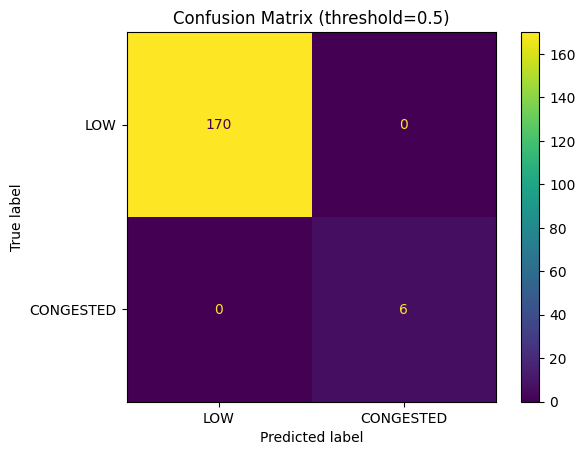

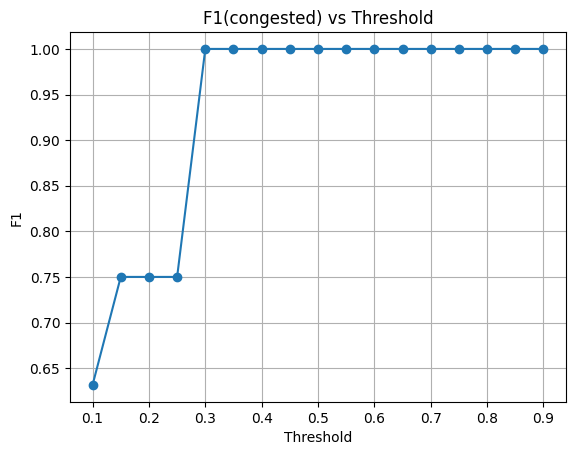

In [ ]:
# ==== Evaluasi model ====
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test, dtype=torch.float32)).numpy().reshape(-1)

probs = 1 / (1 + np.exp(-logits))
pred = (probs >= 0.5).astype(int)

print(classification_report(y_test, pred, target_names=["NOT_CONGESTED(LOW)", "CONGESTED(MED/HEAVY)"]))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["LOW", "CONGESTED"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (threshold=0.5)")
plt.show()

# Kurva sederhana: F1 untuk berbagai threshold
ths = np.linspace(0.1, 0.9, 17)
f1s = []
for t in ths:
    p = (probs >= t).astype(int)
    tp = int(((p == 1) & (y_test == 1)).sum())
    fp = int(((p == 1) & (y_test == 0)).sum())
    fn = int(((p == 0) & (y_test == 1)).sum())
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    f1s.append(f1)

plt.figure()
plt.plot(ths, f1s, marker="o")
plt.title("F1(congested) vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.grid(True)
plt.show()


## 5) Decision: GO / NOT GO

Kebijakan sederhana untuk demo:

- Hitung `prob_congested` dari model
- Jika `prob_congested >= threshold` → **NOT GO**
- Jika `< threshold` → **GO**

Threshold dibuat **slider** di app sehingga bisa “fine-tuning” sesuai risk appetite.


In [ ]:
def predict_proba_from_x(x01: np.ndarray) -> float:
    # x01 shape: (1, 6), dtype float32, berisi 0/1 untuk tiap gate
    model.eval()
    with torch.no_grad():
        logit = model(torch.tensor(x01, dtype=torch.float32)).numpy().reshape(-1)[0]
    prob = float(1 / (1 + np.exp(-logit)))
    return prob

def rule_label_from_inputs(x01: np.ndarray) -> str:
    total = int(x01.sum())
    if 1 <= total <= 2: return "LOW"
    if 3 <= total <= 4: return "MEDIUM"
    if 5 <= total <= 6: return "HEAVY"
    return "UNKNOWN"

def decision(prob_congested: float, threshold: float = 0.5) -> str:
    return "NOT GO" if prob_congested >= threshold else "GO"

# contoh quick test
x_example = np.array([[1,0,1,0,0,0]], dtype=np.float32)
p = predict_proba_from_x(x_example)
print("prob_congested:", round(p, 4), "| decision:", decision(p, 0.5), "| rule_label:", rule_label_from_inputs(x_example))


prob_congested: 0.0149 | decision: GO | rule_label: LOW


## 6) APP (di notebook) dengan Gradio

UI ini yang bisa Anda pakai untuk demo interview:

- **Mode 1:** input manual 6 gate (checkbox)
- **Mode 2:** pilih timestamp historis dari dataset
- Output:
  - probabilitas congested
  - prediksi label (LOW vs CONGESTED)
  - keputusan GO/NOT GO
  - (mode historis) label aktual dari aturan tugas


In [ ]:

# Siapkan list timestamp untuk dropdown (jadikan string supaya aman)
df_ts = df.copy()
df_ts["timestamp_str"] = df_ts["timestamp"].astype(str)
timestamp_options = df_ts["timestamp_str"].tolist()

def _predict_from_inputs(g1, g2, g3, g4, g5, g6, threshold):
    x = np.array([[int(g1), int(g2), int(g3), int(g4), int(g5), int(g6)]], dtype=np.float32)
    prob = predict_proba_from_x(x)
    pred_label = "CONGESTED(MED/HEAVY)" if prob >= threshold else "LOW"
    dec = decision(prob, threshold)
    rule_label = rule_label_from_inputs(x)
    total = int(x.sum())
    return prob, pred_label, dec, rule_label, total

def _predict_from_timestamp(ts_str, threshold):
    row = df_ts[df_ts["timestamp_str"] == ts_str].iloc[0]
    x = row[GATE_COLS].astype(np.float32).values.reshape(1, -1)
    prob = predict_proba_from_x(x)
    pred_label = "CONGESTED(MED/HEAVY)" if prob >= threshold else "LOW"
    dec = decision(prob, threshold)

    actual_label = row["label"]
    total = int(row["total_cars"])
    pattern = row["pattern"]
    return prob, pred_label, dec, actual_label, total, pattern

with gr.Blocks(title="TolJam BI Decision Support") as demo:
    gr.Markdown("# TolJam BI Decision Support (GO / NOT GO)\nMLP fully-connected + BI preprocessing dari data_tol.xlsx")

    with gr.Tab("Manual Input (6 Gate)"):
        gr.Markdown("Centang gate yang **ada mobil** pada timestamp yang ingin disimulasikan.")
        with gr.Row():
            g1 = gr.Checkbox(label="Gate 1 (G1)")
            g2 = gr.Checkbox(label="Gate 2 (G2)")
            g3 = gr.Checkbox(label="Gate 3 (G3)")
        with gr.Row():
            g4 = gr.Checkbox(label="Gate 4 (G4)")
            g5 = gr.Checkbox(label="Gate 5 (G5)")
            g6 = gr.Checkbox(label="Gate 6 (G6)")

        thr1 = gr.Slider(0, 1, value=0.5, step=0.01, label="Threshold (prob_congested)")
        btn1 = gr.Button("Predict & Decide")

        out_prob1 = gr.Number(label="Prob Congested")
        out_pred1 = gr.Textbox(label="Predicted Label (from model)")
        out_dec1 = gr.Textbox(label="Decision")
        out_rule1 = gr.Textbox(label="Rule Label (sesuai definisi tugas)")
        out_total1 = gr.Number(label="Total cars (rule)")

        btn1.click(
            fn=_predict_from_inputs,
            inputs=[g1, g2, g3, g4, g5, g6, thr1],
            outputs=[out_prob1, out_pred1, out_dec1, out_rule1, out_total1],
        )

    with gr.Tab("Historical Timestamp (from dataset)"):
        gr.Markdown("Pilih timestamp historis. Sistem akan ambil fitur 6 gate dari dataset aligned, lalu prediksi & keputusan.")
        ts = gr.Dropdown(choices=timestamp_options, value=timestamp_options[0] if len(timestamp_options) else None, label="Timestamp")
        thr2 = gr.Slider(0, 1, value=0.5, step=0.01, label="Threshold (prob_congested)")
        btn2 = gr.Button("Predict & Decide")

        out_prob2 = gr.Number(label="Prob Congested")
        out_pred2 = gr.Textbox(label="Predicted Label (from model)")
        out_dec2 = gr.Textbox(label="Decision")
        out_actual2 = gr.Textbox(label="Actual Label (rule)")
        out_total2 = gr.Number(label="Total cars")
        out_pattern2 = gr.Textbox(label="Pattern (gate combination)")

        btn2.click(
            fn=_predict_from_timestamp,
            inputs=[ts, thr2],
            outputs=[out_prob2, out_pred2, out_dec2, out_actual2, out_total2, out_pattern2],
        )

    gr.Markdown("Jika running di Colab: setelah `launch()` muncul link, klik untuk membuka UI.")

IN_COLAB = "google.colab" in sys.modules
demo.launch(share=IN_COLAB, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d96ebf03e4956eee8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 7) (Opsional) Download hasil dari Colab

Kalau Anda pakai Colab, Anda bisa download file output (cleaned data + model).


In [ ]:
# (Opsional) Download file hasil (Colab)
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    for f in ["data_tol_aligned.xlsx", "data_tol_clean.csv", "mlp_tolgate.pt"]:
        if os.path.exists(f):
            files.download(f)
else:
    print("Bukan Colab, file sudah tersimpan di folder kerja.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#==========================================================================================================================
#Deep Learning Based Toll Gate Traffic Prediction and Real-Time Decision Support System for Efficient Urban Transportation
#==========================================================================================================================

raw = pd.read_excel('data_tol.xlsx', header=None)
raw.columns = [f'G{i}' for i in range(1, 7)]
raw.head()


,G1,G2,G3,G4,G5,G6
0,1970-01-01 00:00:01,1970-01-01 00:00:00,1970-01-01 00:00:00,1970-01-01 00:00:07,1970-01-01 00:00:00,1970-01-01 00:00:07
1,1970-01-01 00:00:10,1970-01-01 00:00:10,1970-01-01 00:00:09,1970-01-01 00:00:18,1970-01-01 00:00:09,1970-01-01 00:00:30
2,1970-01-01 00:00:20,1970-01-01 00:00:21,1970-01-01 00:00:19,1970-01-01 00:00:27,1970-01-01 00:00:30,1970-01-01 00:00:41
3,1970-01-01 00:00:31,1970-01-01 00:00:31,1970-01-01 00:00:28,1970-01-01 00:01:02,1970-01-01 00:00:41,1970-01-01 00:01:00
4,1970-01-01 00:00:44,1970-01-01 00:00:41,1970-01-01 00:00:38,1970-01-01 00:01:13,1970-01-01 00:00:56,1970-01-01 00:01:16


In [ ]:
#=============
#2. Identify
#=============
#Problem statement
#Raw timestamps are split across six toll gates and are not aligned row-by-row.
#Decision makers need synchronized timestamp rows before any BI or deep learning analysis.
#End users need a recommendation interface: Go, Caution, or Hold.
#Business objective
#Build an application that cleans the dataset, extracts hidden patterns, predicts congestion level, and displays a real-time recommendation dashboard.

records = []
for col in raw.columns:
    for t in raw[col].dropna():
        records.append((pd.to_datetime(t), col, 1))

events = pd.DataFrame(records, columns=['timestamp', 'gate', 'vehicle'])
pivot = events.assign(v=1).pivot_table(index='timestamp', columns='gate', values='v', aggfunc='sum', fill_value=0)
pivot = pivot.reset_index().sort_values('timestamp')
pivot['total_vehicles'] = pivot[[f'G{i}' for i in range(1,7)]].sum(axis=1)

def make_label(n):
    if n <= 2:
        return 'LOW'
    elif n <= 4:
        return 'MEDIUM'
    return 'HEAVY'

pivot['Label'] = pivot['total_vehicles'].apply(make_label)
pivot['seconds'] = (pivot['timestamp'] - pivot['timestamp'].min()).dt.total_seconds().astype(int)
pivot.head()


gate,timestamp,G1,G2,G3,G4,G5,G6,total_vehicles,Label,seconds
0,1970-01-01 00:00:00,0,1,1,0,1,0,3,MEDIUM,0
1,1970-01-01 00:00:01,1,0,0,0,0,0,1,LOW,1
2,1970-01-01 00:00:07,0,0,0,1,0,1,2,LOW,7
3,1970-01-01 00:00:09,0,0,1,0,1,0,2,LOW,9
4,1970-01-01 00:00:10,1,1,0,0,0,0,2,LOW,10


In [ ]:
#===========
#3. Design
#===========
# Save cleaned dataset requested by the assignment
pivot.to_csv('data_tol_clean_rebuilt.csv', index=False)
pivot['Label'].value_counts()


,count
Label,
LOW,852
MEDIUM,27
HEAVY,1


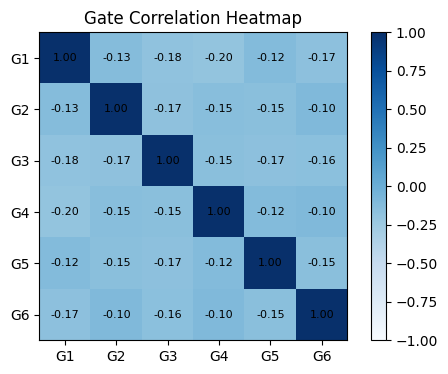

In [ ]:
#============================
#4. Hidden pattern extraction
#============================
#The BI component should reveal hidden structure, not only predictions.
#Gate correlations show whether congestion tends to spread or balance across gates.
#Label distribution shows strong class imbalance.
#Time trend shows peak periods and sparse periods.
corr = pivot[[f'G{i}' for i in range(1,7)]].corr()
plt.figure(figsize=(6,4))
plt.imshow(corr, cmap='Blues', vmin=-1, vmax=1)
plt.xticks(range(6), corr.columns)
plt.yticks(range(6), corr.columns)
plt.colorbar()
for i in range(6):
    for j in range(6):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Gate Correlation Heatmap')
plt.show()


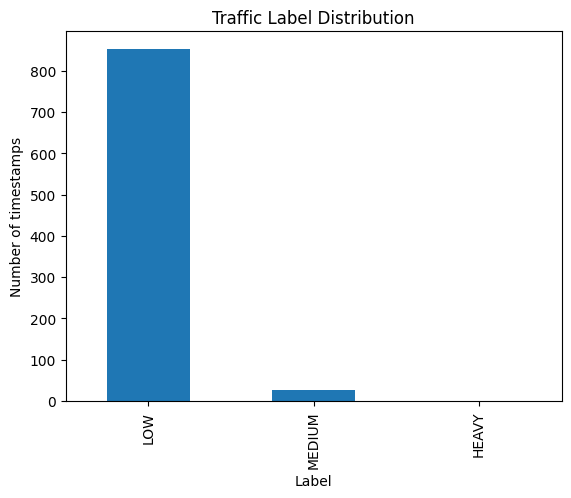

In [ ]:
pivot['Label'].value_counts().reindex(['LOW','MEDIUM','HEAVY']).plot(kind='bar', title='Traffic Label Distribution')
plt.ylabel('Number of timestamps')
plt.show()


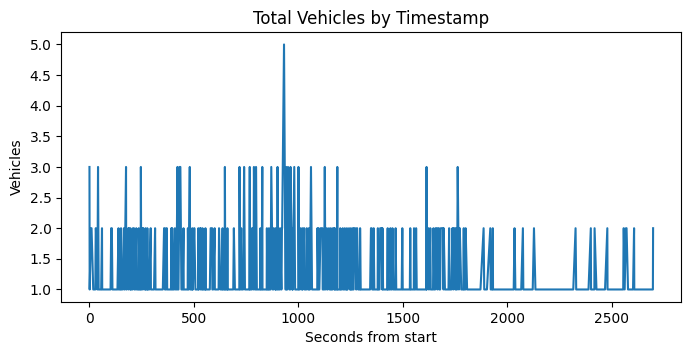

In [ ]:
plt.figure(figsize=(8,3.5))
plt.plot(pivot['seconds'], pivot['total_vehicles'])
plt.title('Total Vehicles by Timestamp')
plt.xlabel('Seconds from start')
plt.ylabel('Vehicles')
plt.show()


In [ ]:
#=======================================
#5. Implementation: Dense Neural Network
#=======================================
#This project uses a fully connected dense neural network.
#The features are the six gate indicators (G1–G6), and the target is the congestion label.

X = pivot[[f'G{i}' for i in range(1,7)]].values
y = pivot['Label'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

model = MLPClassifier(
    hidden_layer_sizes=(32, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)
model.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(32, 64, 32), max_iter=300, random_state=42)

In [ ]:
#=========================
#6. Hyperparameter tuning
#=========================
#The main tuned parameters are:
#
#hidden layers: (32, 64, 32)
#optimizer: Adam
#learning rate: 0.001
#max iterations: 300
#This keeps the model simple enough for the dataset size while still satisfying
#the deep learning requirement through a dense neural architecture.

pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred, labels=[0,1,2])

print('Accuracy:', round(acc, 4))
print('\nClasses:', le.classes_)
print('\nClassification report:')
print(classification_report(y_test, pred, labels=[0,1,2], target_names=le.classes_, zero_division=0))

Accuracy: 0.9943

Classes: ['HEAVY' 'LOW' 'MEDIUM']

Classification report:
              precision    recall  f1-score   support

       HEAVY       0.00      0.00      0.00         0
         LOW       0.99      1.00      1.00       172
      MEDIUM       1.00      0.75      0.86         4

    accuracy                           0.99       176
   macro avg       0.66      0.58      0.62       176
weighted avg       0.99      0.99      0.99       176



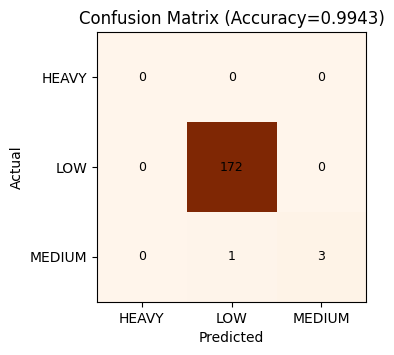

In [ ]:
plt.figure(figsize=(4,3.5))
plt.imshow(cm, cmap='Oranges')
plt.xticks(range(3), le.classes_)
plt.yticks(range(3), le.classes_)
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=9)
plt.title(f'Confusion Matrix (Accuracy={acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
#================================
#7. Real-time prediction function
#================================
#This function is used by the web API and dashboard.
def predict_traffic(g1, g2, g3, g4, g5, g6):
    row = np.array([[g1, g2, g3, g4, g5, g6]])
    pred = model.predict(row)[0]
    label = le.inverse_transform([pred])[0]
    total = int(row.sum())
    recommendation = 'GO' if label == 'LOW' else ('CAUTION' if label == 'MEDIUM' else 'NOT GO')
    return {'label': label, 'total_vehicles': total, 'recommendation': recommendation}

predict_traffic(1,0,1,0,0,0)


{'label': 'LOW', 'total_vehicles': 2, 'recommendation': 'GO'}

In [ ]:
#=========================
#8. Dashboard integration
#=========================
#The app.py file exposes a FastAPI endpoint. The HTML dashboard can call it to update the recommendation status in real time.

# print(Path('app/app.py').read_text()[:1200]) # Commented out: File not found error, as 'app/app.py' does not exist.

In [ ]:
#================
#9. Evaluation
#================
#Key findings
#Accuracy is high because the data is strongly dominated by LOW traffic.
#The rebuilt dataset contains 880 synchronized timestamps.
#Hidden pattern extraction shows the toll system is mostly in a low-congestion state, with very limited HEAVY observations.

#Limitation
#The dataset is highly imbalanced. Future work could include synthetic balancing, richer features, temporal windows, or reinforcement learning for gate-routing policy optimization.

with open('dashboard_live.html', 'r') as f:
    html_content = f.read()
display(HTML(html_content))
